In [ ]:
import torch
import torch.nn as nn
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

In [ ]:
transform = transforms.Compose([transforms.ToTensor(),
                                transforms.Normalize((0.5,), (0.5,))])

In [ ]:
train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = datasets.MNIST(root='./data', train=False, download=True, transform=transform)
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=1000, shuffle=False)

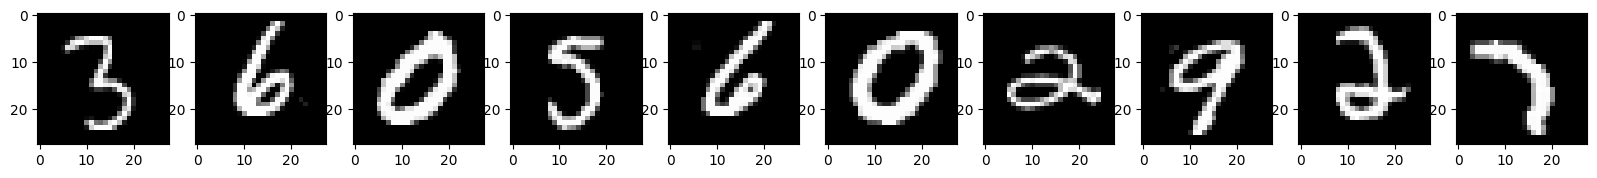

In [ ]:
import matplotlib.pyplot as plt
images , labels = next(iter(train_loader))
fig, axes = plt.subplots(nrows=1, ncols=10, figsize=(20, 3))
for ax, img, label in zip(axes, images, labels):
    ax.imshow(img.squeeze(), cmap='gray')

In [ ]:
class Teacher(nn.Module):
    def __init__(self, hidden1 = 256, hidden2 = 128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(28*28, hidden1),
            nn.ReLU(),
            nn.Linear(hidden1, hidden2),
            nn.ReLU(),
            nn.Linear(hidden2, 10)
        )
    def forward(self, x):
        return self.net(x)

In [ ]:
teacher = Teacher()
print(teacher)

Teacher(
  (net): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=256, bias=True)
    (2): ReLU()
    (3): Linear(in_features=256, out_features=128, bias=True)
    (4): ReLU()
    (5): Linear(in_features=128, out_features=10, bias=True)
  )
)


In [ ]:
def train_teacher(model = teacher, loader = train_loader, epochs=5, lr = 1e-4):
    optimizer = torch.optim.Adam(teacher.parameters(), lr=lr)
    loss_fn = nn.CrossEntropyLoss()

    model.train()
    for epoch in range(epochs):
        for x, y in loader:
            optimizer.zero_grad()
            out = model(x)
            loss = loss_fn(out, y)
            loss.backward()
            optimizer.step()
        print(f"Epoch: {epoch}, Loss: {loss.item()}")

In [ ]:
train_teacher()

Epoch: 0, Loss: 0.31171736121177673
Epoch: 1, Loss: 0.10695582628250122
Epoch: 2, Loss: 0.1051541119813919
Epoch: 3, Loss: 0.054078493267297745
Epoch: 4, Loss: 0.1954311728477478


In [ ]:
class Student(nn.Module):
    def __init__(self, hidden1 = 128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Flatten(),
            nn.Linear(28*28, hidden1),
            nn.ReLU(),
            nn.Linear(hidden1, 10)
        )
    def forward(self, x):
        return self.net(x)

In [ ]:
student = Student()
def pretrain_student(model = student, loader = train_loader, epochs=3, lr = 1e-4):
    model.train()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    ce = nn.CrossEntropyLoss()

    for epoch in range(epochs):
        for x, y in loader:
            optimizer.zero_grad()
            out = model(x)
            loss = ce(out, y)
            loss.backward()
            optimizer.step()
        print(f"Epoch: {epoch}, Loss: {loss.item()}")

In [ ]:
pretrain_student()

Epoch: 0, Loss: 0.3698769211769104
Epoch: 1, Loss: 0.810076892375946
Epoch: 2, Loss: 0.38235077261924744


In [ ]:
temperature = 2
alpha = 0.7
ce_loss = nn.CrossEntropyLoss()
kl_loss = nn.KLDivLoss(reduction="batchmean")
optimizer = torch.optim.Adam(student.parameters(), lr=1e-4)

In [ ]:
def Distil(student, Teacher, loader, epochs = 3):
    for ep in range(epochs):
        student.train()
        for x, y in loader:
            with torch.no_grad():
                teacher_logits = Teacher(x)
                teacher_probs = torch.softmax(teacher_logits / temperature, dim=1)
            student_logits = student(x)
            student_probs = torch.log_softmax(student_logits / temperature, dim=1)
            hard_loss = ce_loss(student_logits, y)
            soft_loss = kl_loss(student_probs, teacher_probs) * (temperature ** 2)
            loss = soft_loss * alpha + hard_loss * (1 - alpha)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
        print(f"Epoch: {ep}, Loss: {loss.item()}")

In [ ]:
Distil(student, teacher, train_loader)

Epoch: 0, Loss: 0.060473233461380005
Epoch: 1, Loss: 0.09979628026485443
Epoch: 2, Loss: 0.05843406543135643


In [ ]:
def evaluate(model, loader, name = "model"):
    model.eval()

    correct , total = 0, 0
    with torch.no_grad():
        for x, y in loader:
            out = model(x).argmax(dim = 1)
            correct += (out == y).sum().item()
            total += y.size(0)
    acc = (correct / total)*100
    print(f"{name} Accuracy: {acc}")

In [ ]:
evaluate(teacher, test_loader, "Teacher")
evaluate(student, test_loader, "Student")

Teacher Accuracy: 95.12
Student Accuracy: 94.89999999999999


In [ ]:
!pip install --upgrade datasets fsspec transformers

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 529.0/529.0 kB 35.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 202.5/202.5 kB 14.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.8/10.8 MB 88.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.9/48.9 MB 13.8 MB/s eta 0:00:00
  Attempting uninstall: pyarrow
    Found existing installation: pyarrow 18.1.0
    Uninstalling pyarrow-18.1.0:
      Successfully uninstalled pyarrow-18.1.0
  Attempting uninstall: fsspec
    Found existing installation: fsspec 2025.3.0
    Uninstalling fsspec-2025.3.0:
      Successfully uninstalled fsspec-2025.3.0
  Attempting uninstall: datasets
    Found existing installation: datasets 4.0.0
    Uninstalling datasets-4.0.0:
      Successfully uninstalled datasets-4.0.0
  Attempting uninstall: transformers
    Found existing installation: transformers 5.0.0
    Uninstalling transformers-5.0.0:
      Successfully uninstalled transformers-5.0.0
ERROR: pip's dependency 

In [ ]:
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from transformers import AutoTokenizer, DataCollatorWithPadding, AutoModelForSequenceClassification
from datasets import load_dataset

In [ ]:
dataset = load_dataset('cardiffnlp/tweet_eval', 'sentiment')

README.md:   0%|          | 0.00/23.9k [00:00<?, ?B/s]

sentiment/train-00000-of-00001.parquet:   0%|          | 0.00/3.78M [00:00<?, ?B/s]

sentiment/test-00000-of-00001.parquet:   0%|          | 0.00/901k [00:00<?, ?B/s]

sentiment/validation-00000-of-00001.parq(…):   0%|          | 0.00/167k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/45615 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/12284 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/2000 [00:00<?, ? examples/s]

In [ ]:
label_dataset = dataset['train'].features['label']

In [ ]:
label_dataset

ClassLabel(names=['negative', 'neutral', 'positive'])

In [ ]:
tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

In [ ]:
#parameters
max_len = 128
batch_size = 16
num_labels = 3
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
lr = 1e-4
epochs = 3
temperature = 2
alpha = 0.8

In [ ]:
def tokenize(example):
    return tokenizer(example['text'], truncation=True, max_length = max_len)

In [ ]:
train = dataset['train'].shuffle(seed = 42).select(range(2500))
val = dataset['validation']

In [ ]:
tokenized = {}
tokenized['train'] = train.map(tokenize, batched = True, remove_columns = ['text'])
tokenized['validation'] = val.map(tokenize, batched = True, remove_columns = ['text'])

Map:   0%|          | 0/2500 [00:00<?, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

In [ ]:
tokenized['train'] = tokenized['train'].rename_column("label", "labels")
tokenized['validation'] = tokenized['validation'].rename_column("label", "labels")

In [ ]:
tokenized['train'].set_format("torch")
tokenized['validation'].set_format("torch")

In [ ]:
datacollator = DataCollatorWithPadding(tokenizer, pad_to_multiple_of= 8)

In [ ]:
train_loaded = DataLoader(tokenized['train'], batch_size = batch_size, shuffle = True, collate_fn = datacollator)
val_loaded = DataLoader(tokenized['validation'], batch_size = batch_size, shuffle = True, collate_fn = datacollator)

In [ ]:
Teacher = AutoModelForSequenceClassification.from_pretrained("bert-large-uncased", num_labels = num_labels).to(device)
Student = AutoModelForSequenceClassification.from_pretrained("bert-base-uncased", num_labels = num_labels).to(device)

config.json:   0%|          | 0.00/571 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.34G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: bert-large-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [ ]:
for p in Teacher.parameters():
    p.requires_grad = False
Teacher.eval()

BertForSequenceClassification(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 1024, padding_idx=0)
      (position_embeddings): Embedding(512, 1024)
      (token_type_embeddings): Embedding(2, 1024)
      (LayerNorm): LayerNorm((1024,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-23): 24 x BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=1024, out_features=1024, bias=True)
              (key): Linear(in_features=1024, out_features=1024, bias=True)
              (value): Linear(in_features=1024, out_features=1024, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=1024, out_features=1024, bias=True)
              (LayerNorm): LayerNorm((1024,

In [ ]:
ce_loss = nn.CrossEntropyLoss()
kl_loss  = nn.KLDivLoss(reduction="batchmean")
optimizer = torch.optim.Adam(Student.parameters(), lr = lr)

In [ ]:
from transformers import get_scheduler
num_training_steps = epochs * len(train_loaded)
lr_scheduler = get_scheduler(
    name="linear", optimizer=optimizer, num_warmup_steps=0, num_training_steps=num_training_steps
)

In [ ]:
from tqdm.auto import tqdm

In [ ]:
tokenized

{'train': Dataset({
     features: ['labels', 'input_ids', 'token_type_ids', 'attention_mask'],
     num_rows: 2500
 }),
 'validation': Dataset({
     features: ['labels', 'input_ids', 'token_type_ids', 'attention_mask'],
     num_rows: 2000
 })}

In [ ]:
def distil_train():

    for ep in range(epochs):
        pbar = tqdm(train_loaded, desc = "Traning")
        Student.train()

        for batch in pbar:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)

            with torch.no_grad():
                teacher_logits = Teacher(input_ids, attention_mask = attention_mask).logits
                teacher_probs = torch.softmax(teacher_logits / temperature, dim = -1)

            student_logits = Student(input_ids, attention_mask = attention_mask).logits
            student_probs = torch.log_softmax(student_logits / temperature, dim = -1)

            hard_loss = ce_loss(student_logits, labels)
            soft_loss = kl_loss(student_probs, teacher_probs) * (temperature ** 2)

            loss = soft_loss * alpha + hard_loss * (1 - alpha)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            lr_scheduler.step()
            pbar.set_postfix(loss=loss.item())

        print(f"Epoch: {ep}, Loss: {loss.item()}")

In [ ]:
def evaluate(model):
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for batch in val_loaded:
            batch = {k: v.to(device) for k, v in batch.items()}
            out = model(**batch).logits.argmax(dim = -1)
            correct += (out == batch['labels']).sum().item()
            total += batch['labels'].size(0)
    acc = (correct / total)*100
    print(f"Accuracy: {acc}")

In [ ]:
distil_train()


Traning:   0%|          | 0/157 [00:00<?, ?it/s]

Epoch: 0, Loss: 0.17049865424633026
Epoch: 1, Loss: 0.162870392203331
Epoch: 2, Loss: 0.1895674169063568


In [ ]:
evaluate(Student)

Accuracy: 67.2


In [ ]:
evaluate(Teacher)

Accuracy: 43.2
